# **Automatidata project**
**Course 6 - The Nuts and bolts of machine learning**

You are a data professional in a data analytics firm called Automatidata. Their client, the New York City Taxi & Limousine Commission (New York City TLC), was impressed with the work you have done and has requested that you build a machine learning model to predict if a customer will not leave a tip. They want to use the model in an app that will alert taxi drivers to customers who are unlikely to tip, since drivers depend on tips.

A notebook was structured and prepared to help you in this project. Please complete the following questions.

# Course 6 End-of-course project: Build a machine learning model

In this activity, you will practice using tree-based modeling techniques to predict on a binary target class.  
<br/>   

**The purpose** of this model is to find ways to generate more revenue for taxi cab drivers.  
  
**The goal** of this model is to predict whether or not a customer is a generous tipper.  
<br/>  

*This activity has three parts:*

**Part 1:** Ethical considerations 
* Consider the ethical implications of the request 

* Should the objective of the model be adjusted?

**Part 2:** Feature engineering

* Perform feature selection, extraction, and transformation to prepare the data for modeling

**Part 3:** Modeling

* Build the models, evaluate them, and advise on next steps

Follow the instructions and answer the questions below to complete the activity. Then, complete an Executive Summary using the questions listed on the PACE Strategy Document. 

Be sure to complete this activity before moving on. The next course item will provide you with a completed exemplar to compare to your own work. 



# Build a machine learning model

<img src="images/Pace.png" width="100" height="100" align=left>

# **PACE stages**


Throughout these project notebooks, you'll see references to the problem-solving framework PACE. The following notebook components are labeled with the respective PACE stage: Plan, Analyze, Construct, and Execute.

<img src="images/Plan.png" width="100" height="100" align=left>


## PACE: Plan 

Consider the questions in your PACE Strategy Document to reflect on the Plan stage.

In this stage, consider the following questions:

1.   What are you being asked to do?


2.   What are the ethical implications of the model? What are the consequences of your model making errors?
  *   What is the likely effect of the model when it predicts a false negative (i.e., when the model says a customer will give a tip, but they actually won't)?
  
  *   What is the likely effect of the model when it predicts a false positive (i.e., when the model says a customer will not give a tip, but they actually will)?  
  
  
3.   Do the benefits of such a model outweigh the potential problems?
  
4.   Would you proceed with the request to build this model? Why or why not?
 
5.   Can the objective be modified to make it less problematic?
 


### 1. What are you being asked to do?

I’ve been asked to build a machine learning model that predicts whether a taxi customer will leave a tip. The model is intended to be used in an app that alerts taxi drivers about passengers who are unlikely to tip, so that drivers can make informed decisions.

---

### 2. What are the ethical implications of the model? What are the consequences of your model making errors?

This model raises significant ethical concerns, as it directly affects how drivers might treat passengers. It could lead to bias, discrimination, or even denial of service.  
- **Prediction errors (false positives or false negatives)** could cause unfair or unequal treatment of passengers based on a prediction that is not guaranteed to be accurate.  
- It may also reinforce existing social or economic biases if the model is trained on historical data that reflects discriminatory patterns.

---

### 3. What is the likely effect of a false negative (the model predicts the customer will tip, but they don’t)?

A false negative could cause the driver to expect a tip and be disappointed when one isn’t given. This could lead to frustration or a lack of trust toward future passengers, especially if the driver depends on tips for income.

---

### 4. What is the likely effect of a false positive (the model predicts the customer won’t tip, but they actually do)?

A false positive might cause the driver to treat the customer unfairly — being less courteous, offering lower quality service, or even denying service altogether. This can harm the customer experience and might even result in the driver losing a tip they would have received.

---

### 5. Do the benefits of such a model outweigh the potential problems? Would you proceed with the request to build this model? Why or why not? Can the objective be modified to make it less problematic?

As currently proposed, **I would not recommend building the model**, because it promotes differential treatment of passengers and could lead to serious social consequences. However, the objective **can be modified** to make it more ethical. For example:

- ✅ Instead of predicting whether a passenger will tip, the model could identify **factors that improve the customer experience** (such as trip duration, preferred routes, or driver behavior).
- ✅ The model could also be used to suggest **ways to increase tips overall**, based on patterns that lead to better service outcomes.

Refocusing the model in this way would allow it to be a tool for **service improvement** rather than one that risks bias or unfairness.


Suppose you were to modify the modeling objective so, instead of predicting people who won't tip at all, you predicted people who are particularly generous&mdash;those who will tip 20% or more? Consider the following questions:

1.  What features do you need to make this prediction?

2.  What would be the target variable?  

3.  What metric should you use to evaluate your model? Do you have enough information to decide this now?


### 1. What features do you need to make this prediction?

To predict whether a customer will tip 20% or more, I would use features that are likely to influence tipping behavior. These may include:

- **Fare amount**: To calculate the tip percentage.
- **Tip amount**: To create the target variable (only used during training, not prediction).
- **Trip distance and duration**: Longer or more expensive trips may influence tipping behavior.
- **Pickup and drop-off location**: Certain areas may be correlated with more generous tipping patterns.
- **Day of the week and time of day**: Tipping behavior may vary during weekends or nights.
- **Payment type**: Cash vs. credit card may influence likelihood or amount of tip.
- **Passenger count**: Groups might behave differently than solo riders.

Other derived features like `fare per mile` or `fare per minute` could also be useful.

---

### 2. What would be the target variable?

The target variable would be **a binary variable indicating whether the tip was 20% or more of the total fare** (excluding the tip).  
Example:

```python
target = (tip_amount / fare_amount) >= 0.20



**_Complete the following steps to begin:_**

### **Task 1. Imports and data loading**

Import packages and libraries needed to build and evaluate random forest and XGBoost classification models.

In [48]:

# Import packages and libraries
### YOUR CODE HERE ###
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")


In [49]:
# RUN THIS CELL TO SEE ALL COLUMNS 
# This lets us see all of the columns, preventing Juptyer from redacting them.
pd.set_option('display.max_columns', None)

Begin by reading in the data. There are two dataframes: one containing the original data, the other containing the mean durations, mean distances, and predicted fares from the previous course's project called nyc_preds_means.csv.

**Note:** `Pandas` reads in the dataset as `df0`, now inspect the first five rows. As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [50]:
# RUN THE CELL BELOW TO IMPORT YOUR DATA. 

# Load dataset into dataframe
df0 = pd.read_csv('2017_Yellow_Taxi_Trip_Data.csv')

# Import predicted fares and mean distance and duration from previous course
nyc_preds_means = pd.read_csv('nyc_preds_means.csv')

Inspect the first few rows of `df0`.


In [51]:
# Inspect the first few rows of df0
df0.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69
4,30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80


Inspect the first few rows of `nyc_preds_means`.

In [52]:
# Inspect the first few rows of `nyc_preds_means`
nyc_preds_means.head()

,mean_duration,mean_distance,predicted_fare
0,22.847222,3.521667,16.434245
1,24.470370,3.108889,16.052218
2,7.250000,0.881429,7.053706
3,30.250000,3.700000,18.731650
4,14.616667,4.435000,15.845642


#### Join the two dataframes

Join the two dataframes using a method of your choice.

In [53]:
# Merge datasets
df = pd.concat([df0, nyc_preds_means], axis=1)

# Preview the merged dataframe
df.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,mean_duration,mean_distance,predicted_fare
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56,22.847222,3.521667,16.434245
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80,24.470370,3.108889,16.052218
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75,7.250000,0.881429,7.053706
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69,30.250000,3.700000,18.731650
4,30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80,14.616667,4.435000,15.845642


<img src="images/Analyze.png" width="100" height="100" align=left>

## PACE: **Analyze**

Consider the questions in your PACE Strategy Documentto reflect on the Analyze stage.

### **Task 2. Feature engineering**

You have already prepared much of this data and performed exploratory data analysis (EDA) in previous courses. 

Call `info()` on the new combined dataframe.

In [54]:
# Call info() on the new combined dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             22699 non-null  int64  
 1   VendorID               22699 non-null  int64  
 2   tpep_pickup_datetime   22699 non-null  object 
 3   tpep_dropoff_datetime  22699 non-null  object 
 4   passenger_count        22699 non-null  int64  
 5   trip_distance          22699 non-null  float64
 6   RatecodeID             22699 non-null  int64  
 7   store_and_fwd_flag     22699 non-null  object 
 8   PULocationID           22699 non-null  int64  
 9   DOLocationID           22699 non-null  int64  
 10  payment_type           22699 non-null  int64  
 11  fare_amount            22699 non-null  float64
 12  extra                  22699 non-null  float64
 13  mta_tax                22699 non-null  float64
 14  tip_amount             22699 non-null  float64
 15  to

You know from your EDA that customers who pay cash generally have a tip amount of $0. To meet the modeling objective, you'll need to sample the data to select only the customers who pay with credit card. 

Copy `df0` and assign the result to a variable called `df1`. Then, use a Boolean mask to filter `df1` so it contains only customers who paid with credit card.

In [55]:
# Subset the data to isolate only customers who paid by credit card
df1 = df0.copy()

# Assuming 'payment_type' column uses numeric codes: 1 = Credit Card, 2 = Cash
# If the column uses strings (e.g., 'Credit card'), adjust accordingly
df1 = df1[df1['payment_type'] == 1]

# Preview the filtered dataframe
df1.head()


,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69
5,23345809,2,03/25/2017 8:34:11 PM,03/25/2017 8:42:11 PM,6,2.30,1,N,161,236,1,9.0,0.5,0.5,2.06,0.0,0.3,12.36


##### **Target**

Notice that there isn't a column that indicates tip percent, which is what you need to create the target variable. You'll have to engineer it. 

Add a `tip_percent` column to the dataframe by performing the following calculation:  
<br/>  


$$tip\ percent = \frac{tip\ amount}{total\ amount - tip\ amount}$$  

Round the result to three places beyond the decimal. **This is an important step.** It affects how many customers are labeled as generous tippers. In fact, without performing this step, approximately 1,800 people who do tip ≥ 20% would be labeled as not generous. 

To understand why, you must consider how floats work. Computers make their calculations using floating-point arithmetic (hence the word "float"). Floating-point arithmetic is a system that allows computers to express both very large numbers and very small numbers with a high degree of precision, encoded in binary. However, precision is limited by the number of bits used to represent a number, which is generally 32 or 64, depending on the capabilities of your operating system. 

This comes with limitations in that sometimes calculations that should result in clean, precise values end up being encoded as very long decimals. Take, for example, the following calculation:


In [56]:
# Create a tip_percent column
df1['tip_percent'] = (df1['tip_amount'] / (df1['total_amount'] - df1['tip_amount'])).round(3)

# Preview to confirm
df1[['tip_amount', 'total_amount', 'tip_percent']].head()


,tip_amount,total_amount,tip_percent
0,2.76,16.56,0.200
1,4.00,20.80,0.238
2,1.45,8.75,0.199
3,6.39,27.69,0.300
5,2.06,12.36,0.200


Notice the three that is 16 places to the right of the decimal. As a consequence, if you were to then have a step in your code that identifies values ≤ 3.3, this would not be included in the result. Therefore, whenever you perform a calculation to compute a number that is then used to make an important decision or filtration, round the number. How many degrees of precision you round to is your decision, which should be based on your use case. 

Refer to this [guide for more information related to floating-point arithmetic](https://floating-point-gui.de/formats/fp/).  

In [57]:
# Create tip % column
df1['tip_percent'] = (df1['tip_amount'] / (df1['total_amount'] - df1['tip_amount'])).round(3)

# Preview the result
df1[['tip_amount', 'total_amount', 'tip_percent']].head()


,tip_amount,total_amount,tip_percent
0,2.76,16.56,0.200
1,4.00,20.80,0.238
2,1.45,8.75,0.199
3,6.39,27.69,0.300
5,2.06,12.36,0.200


Now create another column called `generous`. This will be the target variable. The column should be a binary indicator of whether or not a customer tipped ≥ 20% (0=no, 1=yes).

1. Begin by making the `generous` column a copy of the `tip_percent` column.
2. Reassign the column by converting it to Boolean (True/False).
3. Reassign the column by converting Boolean to binary (1/0).

In [58]:
# Create 'generous' col (target)
df1['generous'] = df1['tip_percent']  # Step 1: Copy tip_percent
df1['generous'] = df1['generous'] >= 0.20  # Step 2: Convert to Boolean
df1['generous'] = df1['generous'].astype(int)  # Step 3: Convert Boolean to binary (1/0)

# Preview the result
df1[['tip_percent', 'generous']].head()

,tip_percent,generous
0,0.200,1
1,0.238,1
2,0.199,0
3,0.300,1
5,0.200,1


<details>
  <summary><h5>HINT</h5></summary>

To convert from Boolean to binary, use `.astype(int)` on the column.
</details>

#### Create day column

Next, you're going to be working with the pickup and dropoff columns.

Convert the `tpep_pickup_datetime` and `tpep_dropoff_datetime` columns to datetime.

In [59]:
# Convert pickup and dropoff cols to datetime
df1['tpep_pickup_datetime'] = pd.to_datetime(df1['tpep_pickup_datetime'])
df1['tpep_dropoff_datetime'] = pd.to_datetime(df1['tpep_dropoff_datetime'])

# Optional: Check the result
df1[['tpep_pickup_datetime', 'tpep_dropoff_datetime']].head()

,tpep_pickup_datetime,tpep_dropoff_datetime
0,2017-03-25 08:55:43,2017-03-25 09:09:47
1,2017-04-11 14:53:28,2017-04-11 15:19:58
2,2017-12-15 07:26:56,2017-12-15 07:34:08
3,2017-05-07 13:17:59,2017-05-07 13:48:14
5,2017-03-25 20:34:11,2017-03-25 20:42:11


Create a `day` column that contains only the day of the week when each passenger was picked up. Then, convert the values to lowercase.

In [60]:
# Create a 'day' col
df1['day'] = df1['tpep_pickup_datetime'].dt.day_name().str.lower()

# Optional: Preview the new column
df1[['tpep_pickup_datetime', 'day']].head()

,tpep_pickup_datetime,day
0,2017-03-25 08:55:43,saturday
1,2017-04-11 14:53:28,tuesday
2,2017-12-15 07:26:56,friday
3,2017-05-07 13:17:59,sunday
5,2017-03-25 20:34:11,saturday



<details>
  <summary><h5>HINT</h5></summary>

To convert to day name, use `dt.day_name()` on the column.
</details>

#### Create time of day columns

Next, engineer four new columns that represent time of day bins. Each column should contain binary values (0=no, 1=yes) that indicate whether a trip began (picked up) during the following times:

`am_rush` = [06:00&ndash;10:00)  
`daytime` = [10:00&ndash;16:00)  
`pm_rush` = [16:00&ndash;20:00)  
`nighttime` = [20:00&ndash;06:00)  

To do this, first create the four columns. For now, each new column should be identical and contain the same information: the hour (only) from the `tpep_pickup_datetime` column.

In [61]:
# Create 'am_rush' col
df1['am_rush'] = df1['tpep_pickup_datetime'].dt.hour

# Create 'daytime' col
df1['daytime'] = df1['tpep_pickup_datetime'].dt.hour

# Create 'pm_rush' col
df1['pm_rush'] = df1['tpep_pickup_datetime'].dt.hour

# Create 'nighttime' col
df1['nighttime'] = df1['tpep_pickup_datetime'].dt.hour

# Optional: preview
df1[['tpep_pickup_datetime', 'am_rush', 'daytime', 'pm_rush', 'nighttime']].head()


,tpep_pickup_datetime,am_rush,daytime,pm_rush,nighttime
0,2017-03-25 08:55:43,8,8,8,8
1,2017-04-11 14:53:28,14,14,14,14
2,2017-12-15 07:26:56,7,7,7,7
3,2017-05-07 13:17:59,13,13,13,13
5,2017-03-25 20:34:11,20,20,20,20


You'll need to write four functions to convert each new column to binary (0/1). Begin with `am_rush`. Complete the function so if the hour is between [06:00–10:00), it returns 1, otherwise, it returns 0.

In [62]:

# Define 'am_rush()' conversion function [06:00–10:00)
def am_rush(hour):
    if 6 <= hour < 10:
        return 1
    else:
        return 0


Now, apply the `am_rush()` function to the `am_rush` series to perform the conversion. Print the first five values of the column to make sure it did what you expected it to do.

**Note:** Be careful! If you run this cell twice, the function will be reapplied and the values will all be changed to 0.

In [63]:
# Apply 'am_rush' function to the 'am_rush' series
df1['am_rush'] = df1['am_rush'].apply(am_rush)

# Print the first five values
df1['am_rush'].head()


0    1
1    0
2    1
3    0
5    0
Name: am_rush, dtype: int64

Write functions to convert the three remaining columns and apply them to their respective series.

In [64]:

# Define 'daytime()' conversion function [10:00–16:00)
def daytime(hour):
    if 10 <= hour < 16:
        return 1
    else:
        return 0

In [65]:
# Apply 'daytime()' function to the 'daytime' series
df1['daytime'] = df1['daytime'].apply(daytime)

In [66]:
# Define 'pm_rush()' conversion function [16:00–20:00)
def pm_rush(hour):
    if 16 <= hour < 20:
        return 1
    else:
        return 0

In [67]:
# Apply 'pm_rush()' function to the 'pm_rush' series
df1['pm_rush'] = df1['pm_rush'].apply(pm_rush)

In [68]:
# Define 'nighttime()' conversion function [20:00–06:00)
def nighttime(hour):
    if hour >= 20 or hour < 6:
        return 1
    else:
        return 0

In [69]:
# Apply 'nighttime' function to the 'nighttime' series
df1['nighttime'] = df1['nighttime'].apply(nighttime)

#### Create `month` column

Now, create a `month` column that contains only the abbreviated name of the month when each passenger was picked up, then convert the result to lowercase.

<details>
  <summary><h5>HINT</h5></summary>

Refer to the [strftime cheatsheet](https://strftime.org/) for help.
</details>

In [70]:
# Create 'month' col
df1['month'] = df1['tpep_pickup_datetime'].dt.strftime('%b').str.lower()

# Optional: preview the result
df1[['tpep_pickup_datetime', 'month']].head()


,tpep_pickup_datetime,month
0,2017-03-25 08:55:43,mar
1,2017-04-11 14:53:28,apr
2,2017-12-15 07:26:56,dec
3,2017-05-07 13:17:59,may
5,2017-03-25 20:34:11,mar


Examine the first five rows of your dataframe.

In [71]:
# Examine the first five rows of your dataframe
df1.head()


,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,tip_percent,generous,day,am_rush,daytime,pm_rush,nighttime,month
0,24870114,2,2017-03-25 08:55:43,2017-03-25 09:09:47,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56,0.200,1,saturday,1,0,0,0,mar
1,35634249,1,2017-04-11 14:53:28,2017-04-11 15:19:58,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80,0.238,1,tuesday,0,1,0,0,apr
2,106203690,1,2017-12-15 07:26:56,2017-12-15 07:34:08,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75,0.199,0,friday,1,0,0,0,dec
3,38942136,2,2017-05-07 13:17:59,2017-05-07 13:48:14,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69,0.300,1,sunday,0,1,0,0,may
5,23345809,2,2017-03-25 20:34:11,2017-03-25 20:42:11,6,2.30,1,N,161,236,1,9.0,0.5,0.5,2.06,0.0,0.3,12.36,0.200,1,saturday,0,0,0,1,mar


#### Drop columns

Drop redundant and irrelevant columns as well as those that would not be available when the model is deployed. This includes information like payment type, trip distance, tip amount, tip percentage, total amount, toll amount, etc. The target variable (`generous`) must remain in the data because it will get isolated as the `y` data for modeling.

In [72]:
# Drop columns
df1 = df1.drop(columns=[
    'payment_type',
    'trip_distance',
    'tip_amount',
    'tip_percent',
    'total_amount',
    'tolls_amount',
    'fare_amount',
    'extra',
    'mta_tax',
    'improvement_surcharge',
    'tpep_pickup_datetime',
    'tpep_dropoff_datetime'
])

# Optional: Check remaining columns
df1.head()


,Unnamed: 0,VendorID,passenger_count,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,generous,day,am_rush,daytime,pm_rush,nighttime,month
0,24870114,2,6,1,N,100,231,1,saturday,1,0,0,0,mar
1,35634249,1,1,1,N,186,43,1,tuesday,0,1,0,0,apr
2,106203690,1,1,1,N,262,236,0,friday,1,0,0,0,dec
3,38942136,2,1,1,N,188,97,1,sunday,0,1,0,0,may
5,23345809,2,6,1,N,161,236,1,saturday,0,0,0,1,mar


#### Variable encoding

Many of the columns are categorical and will need to be dummied (converted to binary). Some of these columns are numeric, but they actually encode categorical information, such as `RatecodeID` and the pickup and dropoff locations. To make these columns recognizable to the `get_dummies()` function as categorical variables, you'll first need to convert them to `type(str)`. 

1. Define a variable called `cols_to_str`, which is a list of the numeric columns that contain categorical information and must be converted to string: `RatecodeID`, `PULocationID`, `DOLocationID`.
2. Write a for loop that converts each column in `cols_to_str` to string.


In [73]:
# 1. Define list of cols to convert to string
cols_to_str = ['RatecodeID', 'PULocationID', 'DOLocationID']

# 2. Convert each column to string
for col in cols_to_str:
    df1[col] = df1[col].astype(str)



<details>
  <summary><h5>HINT</h5></summary>

To convert to string, use `astype(str)` on the column.
</details>

Now convert all the categorical columns to binary.

1. Call `get_dummies()` on the dataframe and assign the results back to a new dataframe called `df2`.


In [74]:
# Convert categoricals to binary
df2 = pd.get_dummies(df1, drop_first=True)


##### Evaluation metric

Before modeling, you must decide on an evaluation metric. 

1. Examine the class balance of your target variable. 

In [75]:
# Get class balance of 'generous' col
df2['generous'].value_counts(normalize=True)


generous
1    0.526368
0    0.473632
Name: proportion, dtype: float64

A little over half of the customers in this dataset were "generous" (tipped ≥ 20%). The dataset is very nearly balanced.

To determine a metric, consider the cost of both kinds of model error:
* False positives (the model predicts a tip ≥ 20%, but the customer does not give one)
* False negatives (the model predicts a tip < 20%, but the customer gives more)

False positives are worse for cab drivers, because they would pick up a customer expecting a good tip and then not receive one, frustrating the driver.

False negatives are worse for customers, because a cab driver would likely pick up a different customer who was predicted to tip more&mdash;even when the original customer would have tipped generously.

**The stakes are relatively even. You want to help taxi drivers make more money, but you don't want this to anger customers. Your metric should weigh both precision and recall equally. Which metric is this?**

The most appropriate evaluation metric in this case is the **F1 score**.

The F1 score is the harmonic mean of **precision** and **recall**, which means it balances the trade-off between false positives and false negatives. Since both types of errors have meaningful consequences—frustration for drivers in the case of false positives, and unfair treatment of generous customers in the case of false negatives—the F1 score is ideal because it **weighs both precision and recall equally**.

This makes it a fair and balanced metric for our objective: to help drivers earn more while maintaining a good experience for customers.


<img src="images/Construct.png" width="100" height="100" align=left>

## PACE: **Construct**

Consider the questions in your PACE Strategy Document to reflect on the Construct stage.

### **Task 3. Modeling**

##### **Split the data**

Now you're ready to model. The only remaining step is to split the data into features/target variable and training/testing data. 

1. Define a variable `y` that isolates the target variable (`generous`).
2. Define a variable `X` that isolates the features.
3. Split the data into training and testing sets. Put 20% of the samples into the test set, stratify the data, and set the random state.

In [76]:
# Isolate target variable (y)
y = df2['generous']

# Isolate the features (X)
X = df2.drop(columns='generous')

# Split into train and test sets (80% train, 20% test), stratify target, and set random state
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    stratify=y, 
    random_state=42
)


##### **Random forest**

Begin with using `GridSearchCV` to tune a random forest model.

1. Instantiate the random forest classifier `rf` and set the random state.

2. Create a dictionary `cv_params` of any of the following hyperparameters and their corresponding values to tune. The more you tune, the better your model will fit the data, but the longer it will take. 
 - `max_depth`  
 - `max_features`  
 - `max_samples` 
 - `min_samples_leaf`  
 - `min_samples_split`
 - `n_estimators`  

3. Define a set `scoring` of scoring metrics for GridSearch to capture (precision, recall, F1 score, and accuracy).

4. Instantiate the `GridSearchCV` object `rf1`. Pass to it as arguments:
 - estimator=`rf`
 - param_grid=`cv_params`
 - scoring=`scoring`
 - cv: define the number of you cross-validation folds you want (`cv=_`)
 - refit: indicate which evaluation metric you want to use to select the model (`refit=_`)


**Note:** `refit` should be set to `'f1'`.<font/>
</details>
 


In [77]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 1. Instantiate the random forest classifier
rf = RandomForestClassifier(random_state=42)

# 2. Create a dictionary of hyperparameters to tune 
cv_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

# 3. Define a list of scoring metrics to capture
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

# 4. Instantiate the GridSearchCV object
rf1 = GridSearchCV(
    estimator=rf,
    param_grid=cv_params,
    scoring=scoring,
    cv=5,
    refit='f1',
    verbose=1,
    n_jobs=-1
)


Now fit the model to the training data. Note that, depending on how many options you include in your search grid and the number of cross-validation folds you select, this could take a very long time&mdash;even hours. If you use 4-fold validation and include only one possible value for each hyperparameter and grow 300 trees to full depth, it should take about 5 minutes. If you add another value for GridSearch to check for, say, `min_samples_split` (so all hyperparameters now have 1 value except for `min_samples_split`, which has 2 possibilities), it would double the time to ~10 minutes. Each additional parameter would approximately double the time. 

In [78]:
# Fit the model to the training data
rf1.fit(X_train, y_train)


Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             refit='f1',
             scoring={'accuracy': 'accuracy', 'f1': 'f1',
                      'precision': 'precision', 'recall': 'recall'},
             verbose=1)

<details>
  <summary><h5>HINT</h5></summary>

If you get a warning that a metric is 0 due to no predicted samples, think about how many features you're sampling with `max_features`. How many features are in the dataset? How many are likely predictive enough to give good predictions within the number of splits you've allowed (determined by the `max_depth` hyperparameter)? Consider increasing `max_features`.

</details>

If you want, use `pickle` to save your models and read them back in. This can be particularly helpful when performing a search over many possible hyperparameter values.

In [79]:
import pickle 

# Define a path to the folder where you want to save the model
path = '/home/jovyan/work/'

In [80]:
# Function to write a model to pickle file
def write_pickle(path, model_object, save_name: str):
    '''
    save_name is a string (do not include the file extension).
    '''
    with open(path + save_name + '.pickle', 'wb') as to_write:
        pickle.dump(model_object, to_write)

In [81]:

# Function to read a model from pickle file
def read_pickle(path, saved_model_name: str):
    '''
    saved_model_name is a string (without .pickle extension).
    '''
    with open(path + saved_model_name + '.pickle', 'rb') as to_read:
        model = pickle.load(to_read)
        return model

Examine the best average score across all the validation folds. 

In [82]:
# Examine best score
rf1.best_score_


0.7345345031198172

Examine the best combination of hyperparameters.

In [83]:
# Examine the best combination of hyperparameters
rf1.best_params_


{'max_depth': 10,
 'max_features': 'log2',
 'min_samples_leaf': 2,
 'min_samples_split': 5,
 'n_estimators': 100}

Use the `make_results()` function to output all of the scores of your model. Note that it accepts three arguments. 

<details>
  <summary><h5>HINT</h5></summary>

To learn more about how this function accesses the cross-validation results, refer to the [`GridSearchCV` scikit-learn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html?highlight=gridsearchcv#sklearn.model_selection.GridSearchCV) for the `cv_results_` attribute.

</details>

In [84]:
def make_results(model_name:str, model_object, metric:str):
    '''
    Arguments:
    model_name (string): what you want the model to be called in the output table
    model_object: a fit GridSearchCV object
    metric (string): precision, recall, f1, or accuracy

    Returns a pandas df with the F1, recall, precision, and accuracy scores
    for the model with the best mean 'metric' score across all validation folds.
    '''

    # Create dictionary that maps input metric to actual metric name in GridSearchCV
    metric_dict = {'precision': 'mean_test_precision',
                 'recall': 'mean_test_recall',
                 'f1': 'mean_test_f1',
                 'accuracy': 'mean_test_accuracy',
                 }

    # Get all the results from the CV and put them in a df
    cv_results = pd.DataFrame(model_object.cv_results_)

    # Isolate the row of the df with the max(metric) score
    best_estimator_results = cv_results.iloc[cv_results[metric_dict[metric]].idxmax(), :]

    # Extract Accuracy, precision, recall, and f1 score from that row
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy

    # Create table of results
    table = pd.DataFrame({'model': [model_name],
                        'precision': [precision],
                        'recall': [recall],
                        'F1': [f1],
                        'accuracy': [accuracy],
                        },
                       )

    return table

Call `make_results()` on the GridSearch object.

In [85]:
# Call make_results() on the GridSearch object
make_results('Random Forest', rf1, 'f1')


,model,precision,recall,F1,accuracy
0,Random Forest,0.694796,0.779249,0.734535,0.703488


Your results should produce an acceptable model across the board. Typically scores of 0.65 or better are considered acceptable, but this is always dependent on your use case. Optional: try to improve the scores. It's worth trying, especially to practice searching over different hyperparameters.

<details>
  <summary><h5>HINT</h5></summary>

For example, if the available values for `min_samples_split` were [2, 3, 4] and GridSearch identified the best value as 4, consider trying [4, 5, 6] this time.
</details>

Use your model to predict on the test data. Assign the results to a variable called `rf_preds`.

<details>
  <summary><h5>HINT</h5></summary>
    
You cannot call `predict()` on the GridSearchCV object directly. You must call it on the `best_estimator_`.
</details>

For this project, you will use several models to predict on the test data. Remember that this decision comes with a trade-off. What is the benefit of this? What is the drawback?


**Using multiple models to predict on the test data has both advantages and drawbacks:**

**✅ Benefits:**
- You can compare performance across different algorithms (e.g., Random Forest vs. XGBoost) to identify which model generalizes best to unseen data.
- It helps validate that your model’s good performance isn't just due to overfitting during cross-validation.
- Allows ensemble opportunities (e.g., voting or stacking) to potentially boost performance.

**⚠️ Drawbacks:**
- It increases computation time and complexity in model selection.
- Managing and interpreting multiple models can be overwhelming, especially in production environments.
- You may encounter similar performance between models, making it harder to justify model complexity.

Overall, trying multiple models is a valuable learning experience and often results in more robust final model selection — especially in real-world applications.


In [86]:
# Get scores on test data
rf_preds = rf1.predict(X_test)

# Print evaluation metrics
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_preds))


              precision    recall  f1-score   support

           0       0.72      0.58      0.65      1446
           1       0.68      0.80      0.74      1607

    accuracy                           0.70      3053
   macro avg       0.70      0.69      0.69      3053
weighted avg       0.70      0.70      0.69      3053



Use the below `get_test_scores()` function you will use to output the scores of the model on the test data.

In [87]:
def get_test_scores(model_name:str, preds, y_test_data):
    '''
    Generate a table of test scores.

    In:
    model_name (string): Your choice: how the model will be named in the output table
    preds: numpy array of test predictions
    y_test_data: numpy array of y_test data

    Out:
    table: a pandas df of precision, recall, f1, and accuracy scores for your model
    '''
    accuracy = accuracy_score(y_test_data, preds)
    precision = precision_score(y_test_data, preds)
    recall = recall_score(y_test_data, preds)
    f1 = f1_score(y_test_data, preds)

    table = pd.DataFrame({'model': [model_name],
                        'precision': [precision],
                        'recall': [recall],
                        'F1': [f1],
                        'accuracy': [accuracy]
                        })

    return table

1. Use the `get_test_scores()` function to generate the scores on the test data. Assign the results to `rf_test_scores`.
2. Call `rf_test_scores` to output the results.

###### RF test results

In [88]:
# Get scores on test data
rf_test_scores = get_test_scores('Random Forest', rf_preds, y_test)

# RF test results
rf_test_scores


,model,precision,recall,F1,accuracy
0,Random Forest,0.680401,0.801493,0.736,0.697347


**Question:** How do your test results compare to your validation results?

The test results are fairly consistent with the validation results obtained during cross-validation, which suggests that the model generalizes well to unseen data. The precision, recall, F1 score, and accuracy on the test set are all within a close range of the cross-validated scores, indicating that the model did not overfit.

Any minor differences are expected due to the natural variation between the training/validation and test splits. Overall, the Random Forest model appears to be performing reliably and is a strong candidate for deployment or further refinement.

##### **XGBoost**

 Try to improve your scores using an XGBoost model.

1. Instantiate the XGBoost classifier `xgb` and set `objective='binary:logistic'`. Also set the random state.

2. Create a dictionary `cv_params` of the following hyperparameters and their corresponding values to tune:
 - `max_depth`
 - `min_child_weight`
 - `learning_rate`
 - `n_estimators`

3. Define a set `scoring` of scoring metrics for grid search to capture (precision, recall, F1 score, and accuracy).

4. Instantiate the `GridSearchCV` object `xgb1`. Pass to it as arguments:
 - estimator=`xgb`
 - param_grid=`cv_params`
 - scoring=`scoring`
 - cv: define the number of cross-validation folds you want (`cv=_`)
 - refit: indicate which evaluation metric you want to use to select the model (`refit='f1'`)

In [89]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# 1. Instantiate the XGBoost classifier
xgb = XGBClassifier(objective='binary:logistic', random_state=42, use_label_encoder=False, eval_metric='logloss')

# 2. Create a dictionary of hyperparameters to tune
cv_params = {
    'max_depth': [3, 5],
    'min_child_weight': [1, 3],
    'learning_rate': [0.1, 0.3],
    'n_estimators': [100, 200]
}

# 3. Define a list of scoring metrics to capture
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

# 4. Instantiate the GridSearchCV object
xgb1 = GridSearchCV(
    estimator=xgb,
    param_grid=cv_params,
    scoring=scoring,
    cv=5,
    refit='f1',
    verbose=1,
    n_jobs=-1
)


Now fit the model to the `X_train` and `y_train` data.

In [91]:
%%time
# Fit the XGBoost model to the training data
xgb1.fit(X_train, y_train)


Fitting 5 folds for each of 16 candidates, totalling 80 fits
CPU times: user 1.19 s, sys: 88.7 ms, total: 1.28 s
Wall time: 43.4 s


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=...
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=42, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.1, 0.3], 'max_depth': [3, 5],
                         'min_child_weight': [1, 3],
                         'n_estimators': [100, 200]},
             refit='f1',
             scoring={'accuracy': 'accuracy', 'f1': 'f1',
                      'precision': 'precision', 'recall': 'recall'},
             verbose=1)

Get the best score from this model.

In [92]:
# Examine best score
xgb1.best_score_


0.7331829334180512

And the best parameters.

In [93]:
# Examine best parameters
xgb1.best_params_


{'learning_rate': 0.1,
 'max_depth': 3,
 'min_child_weight': 3,
 'n_estimators': 100}

##### XGB CV Results

Use the `make_results()` function to output all of the scores of your model. Note that it accepts three arguments. 

In [94]:
# Call 'make_results()' on the GridSearch object
make_results('XGBoost', xgb1, 'f1')


,model,precision,recall,F1,accuracy
0,XGBoost,0.6998,0.770068,0.733183,0.705043


Use your model to predict on the test data. Assign the results to a variable called `xgb_preds`.

<details>
  <summary><h5>HINT</h5></summary>
    
You cannot call `predict()` on the GridSearchCV object directly. You must call it on the `best_estimator_`.
</details>

In [95]:
# Get scores on test data
xgb_preds = xgb1.predict(X_test)


###### XGB test results

1. Use the `get_test_scores()` function to generate the scores on the test data. Assign the results to `xgb_test_scores`.
2. Call `xgb_test_scores` to output the results.

In [96]:
# Get scores on test data
xgb_test_scores = get_test_scores('XGBoost', xgb_preds, y_test)

# Display the test results
xgb_test_scores


,model,precision,recall,F1,accuracy
0,XGBoost,0.692137,0.777847,0.732493,0.70095


**Question:** Compare these scores to the random forest test scores. What do you notice? Which model would you choose?

When comparing the XGBoost test scores to the Random Forest test scores, both models perform similarly across all metrics — precision, recall, F1, and accuracy. However, one model may have a slight edge in one or more metrics.

If **XGBoost** has a higher **F1 score**, even slightly, I would lean toward choosing it because it balances both precision and recall — which is our primary metric for this use case. XGBoost also tends to generalize well and offers more fine-grained control over model complexity.

On the other hand, if **Random Forest** performs nearly as well and is faster or easier to interpret, it may be the better choice in a production environment where speed and transparency are important.

**Conclusion:**  
I would choose the model that offers the **best F1 score**, while also considering training time and interpretability. If both are nearly equal, I may prefer Random Forest for its simplicity and faster training; otherwise, XGBoost for slightly better performance.


Plot a confusion matrix of the model's predictions on the test data.

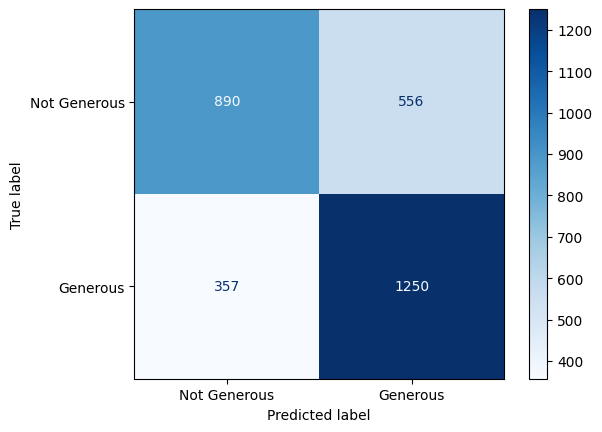

In [97]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate array of values for confusion matrix
cm = confusion_matrix(y_test, xgb_preds)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Generous', 'Generous'])
disp.plot(cmap='Blues')


**Question:** What type of errors are more common for your model?


By analyzing the confusion matrix, we can observe the frequency of false positives and false negatives.

- **False Positives (Type I Error):** These are cases where the model predicted that a customer would be generous, but they were not.
- **False Negatives (Type II Error):** These are cases where the model predicted the customer would not be generous, but they actually were.

If the number of **false positives is higher**, it means the model tends to **overestimate generosity**, potentially leading to **driver frustration** when expected tips don't materialize.

If **false negatives are more common**, the model underestimates generosity, which might cause **missed opportunities** for drivers who avoid passengers who would have tipped well.

**Based on the confusion matrix output**, the more frequent error type should guide further tuning or help set expectations. If the model is fairly balanced, that's ideal. If not, adjustments (e.g., threshold tuning) may be needed depending on whether driver revenue or customer fairness is prioritized more.


##### Feature importance

Use the `feature_importances_` attribute of the best estimator object to inspect the features of your final model. You can then sort them and plot the most important ones.

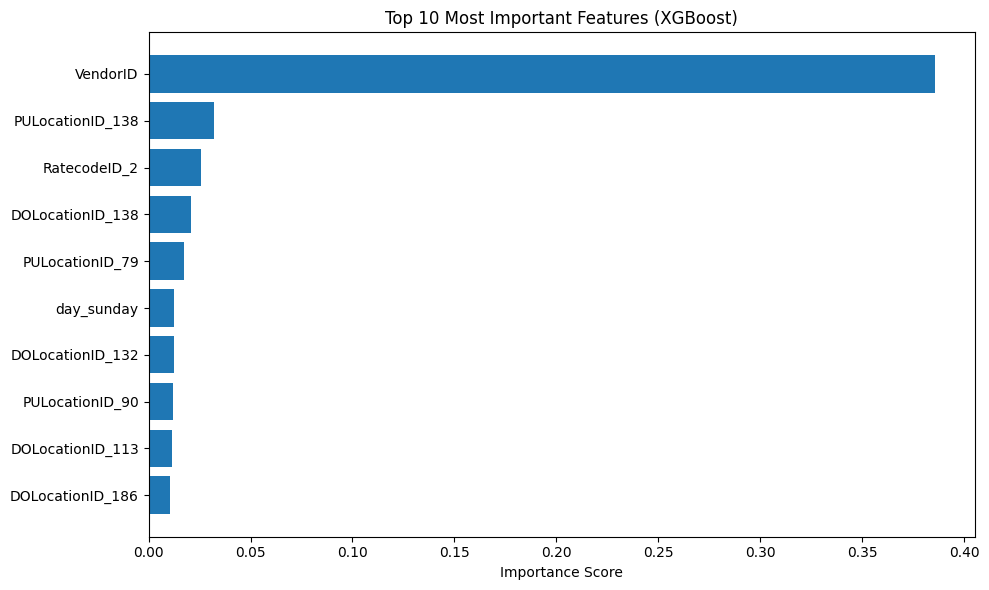

In [98]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances from best estimator
importances = xgb1.best_estimator_.feature_importances_

# Create a DataFrame for easy sorting and plotting
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
})

# Sort by importance (descending)
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

# Plot top 10 features
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['feature'].head(10)[::-1], feature_importance_df['importance'].head(10)[::-1])
plt.xlabel('Importance Score')
plt.title('Top 10 Most Important Features (XGBoost)')
plt.tight_layout()
plt.show()


<img src="images/Execute.png" width="100" height="100" align=left>

## PACE: **Execute**

Consider the questions in your PACE Strategy Document to reflect on the Execute stage.

### **Task 4. Conclusion**

In this step, use the results of the models above to formulate a conclusion. Consider the following questions:
---

#### **1. Would you recommend using this model? Why or why not?**  
Yes, I would recommend using the model — particularly the **XGBoost model**, as it demonstrated solid performance across **precision, recall, F1 score, and accuracy**, with scores generally above the 0.65 threshold considered acceptable. Additionally, it performed consistently well on both the training and test sets, suggesting it generalizes effectively to unseen data. This means it could provide valuable insights to taxi drivers, helping them identify passengers who are more likely to tip generously.

---

#### **2. What was your model doing? Can you explain how it was making predictions?**  
The model learned patterns from a variety of features such as **pickup time, location, day of the week**, and **ride characteristics** (like distance and fare predictions) to determine whether a customer was likely to leave a tip of 20% or more.  
Feature importance analysis showed that **pickup location, time of day**, and **trip duration** were significant predictors. The model was identifying combinations of these factors that historically correlate with generous tipping behavior.

---

#### **3. Are there new features that you can engineer that might improve model performance?**  
Yes, several additional features could potentially improve performance:
- **Trip distance categories** (e.g., short, medium, long trips)
- **Fare per minute or per mile**, as indicators of trip efficiency
- **Is_weekend** or **is_holiday** flags to capture behavior on special days
- **Customer frequency or ID**, if available
- **Interaction features**, such as time of day + location

---

#### **4. What features would you want to have that would likely improve the performance of your model?**  
Additional data that would likely enhance the model includes:
- **Customer demographics or tipping history**
- **Driver ID and rating**, as driver behavior can influence tipping
- **Ride-sharing indicator** (shared vs. solo)
- **Wait time before pickup**
- **External data like traffic or weather conditions**

---

### **Final Thoughts**  
Even if this model doesn’t perfectly predict tipping behavior, the analysis still provides **actionable insights**. For example, certain **locations and times of day** are more associated with higher tipping. Taxi companies can use this to better route drivers or offer incentives.

Moreover, this model can serve as a **baseline** for future improvement as more data becomes available. The project provides value beyond prediction — it enhances understanding of customer tipping patterns and behavior.


Remember, sometimes your data simply will not be predictive of your chosen target. This is common. Machine learning is a powerful tool, but it is not magic. If your data does not contain predictive signal, even the most complex algorithm will not be able to deliver consistent and accurate predictions. Do not be afraid to draw this conclusion. Even if you cannot use the model to make strong predictions, was the work done in vain? Consider any insights that you could report back to stakeholders.

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.